1) Load the dataset "sales_data.csv".
2) Calculate the following statistics for the sales
data:
- Total number of products sold.
- Total revenue generated.
- Average price per product.
- Most expensive product.
3) Find the top-selling product category
(category with the highest sales quantity).
4) Filter the dataset to include only products
with a quantity greater than or equal to 10 and
save it as a new DataFrame
5) Calculate the total revenue generated by the
filtered dataset.
6) Calculate the average price per product for
the filtered dataset.
7) Visualize the revenue generated by each
product grouping the categories by colour.
Make a scatter plot that shows each category
in a different colour. See if you can infer
some trends in the data.

### Analysing Sales Data

**Context**: You recently joined a leading e-commerce
company as a data scientist. The company has
provided you with a dataset containing sales data of
various products. Your task is to analyse the dataset
and extract meaningful insights to help improve
business strategies.


**Dataset Description**: The dataset, named
"sales_data.csv," is in CSV (Comma-Separated
Values) format and contains the following columns:

1. ProductID: Unique identifier of the product.
2. Category: Category of the product (*1: Home*,
    *2: Beauty, 3: Electronics, 4: Clothing*)
3. Price: Price of the product.
4. Quantity: Number of units sold.
5. Revenue: Total revenue generated by the
product (Price * Quantity).

**Tasks**:

In [2]:
# import needed libraries
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
# load the dataset into a Pandas DataFrame
data = pd.read_csv("sales_data.csv")

In [4]:
# visualise pd DataFrame
data

,ProductID,Category,Price,Quantity,Revenue
0,1,3,454.271968,13,5905.535587
1,2,4,147.296341,16,2356.741460
2,3,1,434.546327,13,5649.102250
3,4,3,406.003947,4,1624.015790
4,5,3,882.684716,4,3530.738865
...,...,...,...,...,...
9995,9996,4,198.756211,4,795.024843
9996,9997,3,260.018505,15,3900.277571
9997,9998,2,29.223117,6,175.338704
9998,9999,2,142.933087,1,142.933087


In [5]:
# calculate total number of products sold

total_products_sold = data['Quantity'].sum()
print(f'Total no. of products sold: {total_products_sold}')

Total no. of products sold: 100333


In [6]:
# calculate total revenue

total_revenue = data['Revenue'].sum()
print(f'Total revenue: £ {total_revenue:.2f}')

Total revenue: £ 27397488.45


In [7]:
# calculate average price per product

average_price = data['Price'].mean()
print(f'Average price: £ {average_price:.2f}')

Average price: £ 270.17


In [8]:
# find the most expensive product and its details

most_expensive_prod = data['ProductID'][data['Price'].argmax()]
print(f'most expensive productID: {most_expensive_prod}')

data.iloc[1123]

most expensive productID: 1124


ProductID    1124.000000
Category        3.000000
Price         999.514613
Quantity        1.000000
Revenue       999.514613
Name: 1123, dtype: float64

In [9]:
# find top selling category index and corresponding name

# define dictionary associating category indices to names
category_names = {1: "Home",
                  2: "Beauty",
                  3: "Electronics",
                  4: "Clothing"}

In [10]:
# find number of products sold per category

data.groupby('Category')['Quantity'].sum()

Category
1    25588
2    24486
3    25429
4    24830
Name: Quantity, dtype: int64

In [11]:
# find index of top selling category

cat_max = data.groupby('Category')['Quantity'].sum().idxmax()

In [12]:
# print top selling category name

print(f'Top category: {category_names[cat_max]}')

Top category: Home


In [13]:
# filter data based on number of sold products (e.g. n >= 10)

filtered_data = data[data['Quantity']>=10]

In [14]:
# show filtered dataset

filtered_data

,ProductID,Category,Price,Quantity,Revenue
0,1,3,454.271968,13,5905.535587
1,2,4,147.296341,16,2356.741460
2,3,1,434.546327,13,5649.102250
5,6,4,35.558985,11,391.148835
6,7,1,399.559297,14,5593.830154
...,...,...,...,...,...
9985,9986,4,141.290374,13,1836.774858
9988,9989,2,140.196085,10,1401.960845
9992,9993,2,62.744403,16,1003.910453
9994,9995,4,229.908657,13,2988.812540


In [15]:
# select revenue column from filtered data

filtered_data['Revenue']

0       5905.535587
1       2356.741460
2       5649.102250
5        391.148835
6       5593.830154
           ...     
9985    1836.774858
9988    1401.960845
9992    1003.910453
9994    2988.812540
9996    3900.277571
Name: Revenue, Length: 5299, dtype: float64

In [16]:
# calculate total revenue of filtered data

total_filtered_revenue = filtered_data['Revenue'].sum()

In [17]:
# print total revenue of filtered data
print(f'Filtered data revenue: £ {total_filtered_revenue:.2f}') 

Filtered data revenue: £ 21155903.04


In [18]:
# calculate average price of filtered data

avg_price_filtered = filtered_data['Price'].mean()
print(f'average price filtered: £ {avg_price_filtered:.2f}')

average price filtered: £ 274.12


In [19]:
import seaborn as sns

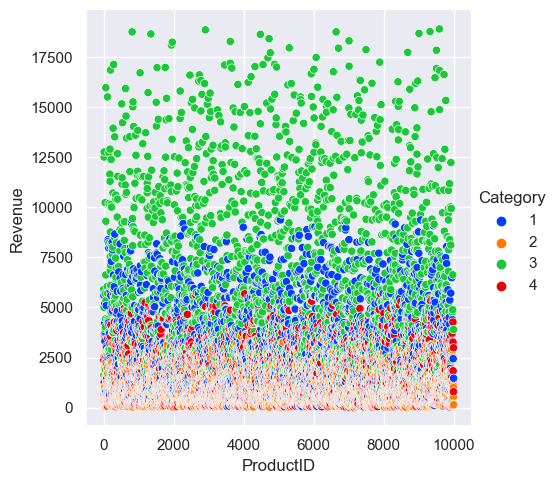

In [20]:
# visualise revenue per category 
sns.set_theme(rc={'figure.figsize':(10,6)})
palette = sns.color_palette("bright", 4)
sns.relplot(data, x='ProductID', y='Revenue', hue='Category', palette= palette)